# Entrenamiento y Prueba de YOLO para Deepfakes

Este cuaderno es la version limpia y refinada del flujo principal del proyecto.

Objetivos:
- validar que el dataset esta en el formato correcto para YOLO Classification
- lanzar un entrenamiento configurable y reproducible
- probar el modelo entrenado o el ultimo `best.pt` disponible
- clasificar una imagen local o una imagen descargada desde internet

La idea es que este sea el notebook canonico y que, cuando te convenga, puedas archivar o borrar los cuadernos anteriores.

## 1. Preparacion del entorno

Esta celda detecta la raiz del proyecto, añade `src/` al path de Python y carga las utilidades compartidas del repositorio.

In [32]:
from __future__ import annotations

import sys
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import requests
from PIL import Image


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'src').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('No se encontro la raiz del proyecto.')


PROJECT_ROOT = find_project_root()
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from detector_deepfake.config import ensure_yolo_dataset_layout, get_dataset_dir, get_runs_dir
from detector_deepfake.inference import classify_image, resolve_model_path
from ultralytics import YOLO

plt.style.use('ggplot')

print(f'Proyecto: {PROJECT_ROOT}')
print(f'SRC cargado: {SRC}')

Proyecto: D:\proyectos\Detector de ia
SRC cargado: D:\proyectos\Detector de ia\src


## 2. Configuracion del flujo



Ajusta aqui los parametros del entrenamiento y de la prueba.



Notas practicas:

- En Windows, `WORKERS = 0` es la opcion segura en esta maquina.

- Para pruebas rapidas usa `FRACTION` muy pequeño, por ejemplo `0.001` o `0.01`.

- Si `FRACTION` es menor que `1.0`, YOLO entrena solo con una parte del dataset. No es un corte inesperado: es el comportamiento configurado.

- El entrenamiento solo se ejecuta si `CONFIRM_TRAINING = True`.

- `SAVE_PERIOD` controla cada cuantas epocas se guardan checkpoints intermedios. `-1` deja solo `best.pt` y `last.pt`.

In [33]:
DATASET_DIR = ensure_yolo_dataset_layout(get_dataset_dir())

RUNS_DIR = get_runs_dir()

BASE_MODEL = 'yolov8n-cls.pt'

EXPERIMENT_NAME = 'notebook_clean_demo'



EPOCHS = 5

BATCH = 16

IMGSZ = 224

WORKERS = 0

DEVICE = '0'

FRACTION = 1

SAVE_PERIOD = 1

CACHE_IMAGES = False

CONFIRM_TRAINING = True



USE_LATEST_MODEL = True

MODEL_PATH = None



LOCAL_IMAGE = DATASET_DIR / 'test' / 'fake' / 'fake_041594.jpg'

IMAGE_URL = ''

DOWNLOAD_DIR = PROJECT_ROOT / 'results' / 'generated' / 'downloads'

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)



effective_fraction = FRACTION if 0 < FRACTION <= 1 else 1.0

estimated_train_images = int(90407 * effective_fraction)



print('Configuracion activa:')

print(f'  DATASET_DIR      = {DATASET_DIR}')

print(f'  RUNS_DIR         = {RUNS_DIR}')

print(f'  BASE_MODEL       = {BASE_MODEL}')

print(f'  EXPERIMENT_NAME  = {EXPERIMENT_NAME}')

print(f'  EPOCHS           = {EPOCHS}')

print(f'  BATCH            = {BATCH}')

print(f'  IMGSZ            = {IMGSZ}')

print(f'  WORKERS          = {WORKERS}')

print(f'  DEVICE           = {DEVICE}')

print(f'  FRACTION         = {FRACTION}')

print(f'  SAVE_PERIOD      = {SAVE_PERIOD}')

print(f'  CONFIRM_TRAINING = {CONFIRM_TRAINING}')

print(f'  LOCAL_IMAGE      = {LOCAL_IMAGE}')

print(f'  IMAGE_URL        = {IMAGE_URL or "<vacio>"}')

print(f'  Train aprox.     = {estimated_train_images} imagenes por epoca')

Configuracion activa:
  DATASET_DIR      = C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata
  RUNS_DIR         = D:\proyectos\Detector de ia\runs\classify\runs_yolo
  BASE_MODEL       = yolov8n-cls.pt
  EXPERIMENT_NAME  = notebook_clean_demo
  EPOCHS           = 5
  BATCH            = 16
  IMGSZ            = 224
  WORKERS          = 0
  DEVICE           = 0
  FRACTION         = 1
  SAVE_PERIOD      = 1
  CONFIRM_TRAINING = True
  LOCAL_IMAGE      = C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata\test\fake\fake_041594.jpg
  IMAGE_URL        = <vacio>
  Train aprox.     = 90407 imagenes por epoca


## 3. Validacion del dataset

Esta celda resume cuantas imagenes hay por split y por clase. Tambien sirve para comprobar rapidamente que `train/`, `val/` y `test/` estan disponibles.

In [34]:
def count_images(split_dir: Path) -> dict[str, int]:
    counts: dict[str, int] = {}
    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        counts[class_dir.name] = sum(1 for path in class_dir.rglob('*') if path.is_file())
    return counts


dataset_summary: dict[str, dict[str, int]] = {}
for split in ['train', 'val', 'test']:
    split_dir = DATASET_DIR / split
    if split_dir.exists():
        dataset_summary[split] = count_images(split_dir)

dataset_summary

{'train': {'fake': 41592, 'real': 48815},
 'val': {'fake': 10399, 'real': 11377},
 'test': {'fake': 10399, 'real': 11377}}

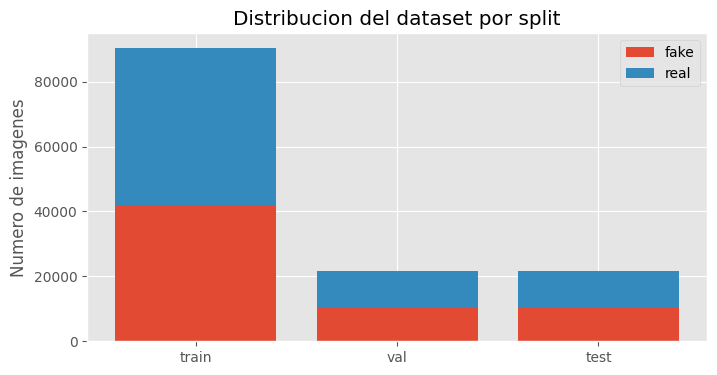

In [35]:
splits = list(dataset_summary.keys())
fake_counts = [dataset_summary[split].get('fake', 0) for split in splits]
real_counts = [dataset_summary[split].get('real', 0) for split in splits]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(splits, fake_counts, label='fake')
ax.bar(splits, real_counts, bottom=fake_counts, label='real')
ax.set_title('Distribucion del dataset por split')
ax.set_ylabel('Numero de imagenes')
ax.legend()
plt.show()

## 4. Entrenamiento de YOLO Classification



Esta celda usa los mismos conceptos que el script `scripts/train.py`, pero desde el notebook.



Aclaraciones importantes:

- Si `FRACTION = 0.001`, el entrenamiento usara aproximadamente el `0.1%` del split `train`. En este dataset eso ronda unas `90` imagenes por epoca.

- Si ves `...` o mensajes como `Output is truncated`, eso viene del visor de salidas del notebook y no significa que el entrenamiento haya fallado o se haya cortado.

- Para evitar entrenar por accidente, la celda no hace nada mientras `CONFIRM_TRAINING` siga en `False`.

In [36]:
if not CONFIRM_TRAINING:

    print('Entrenamiento desactivado. Cambia CONFIRM_TRAINING = True si quieres lanzar una corrida.')

else:

    effective_fraction = FRACTION if 0 < FRACTION <= 1 else 1.0

    estimated_train_images = int(90407 * effective_fraction)

    print(f'[*] Fraccion configurada: {effective_fraction}')

    print(f'[*] Imagenes aproximadas de train por epoca: {estimated_train_images}')

    print(f'[*] Save period: {SAVE_PERIOD} (-1 significa solo best.pt y last.pt)')

    print('[*] Nota: si el notebook muestra salida truncada, es un limite visual del visor de Jupyter en VS Code.')



    model = YOLO(BASE_MODEL)

    train_results = model.train(

        data=str(DATASET_DIR),

        epochs=EPOCHS,

        batch=BATCH,

        workers=WORKERS,

        cache=CACHE_IMAGES,

        imgsz=IMGSZ,

        project=str(RUNS_DIR),

        name=EXPERIMENT_NAME,

        device=DEVICE,

        fraction=FRACTION,

        save_period=SAVE_PERIOD,

        exist_ok=True,

    )

    MODEL_PATH = Path(train_results.save_dir) / 'weights' / 'best.pt'

    print(f'Modelo generado: {MODEL_PATH}')

[*] Fraccion configurada: 1
[*] Imagenes aproximadas de train por epoca: 90407
[*] Save period: 1 (-1 significa solo best.pt y last.pt)
[*] Nota: si el notebook muestra salida truncada, es un limite visual del visor de Jupyter en VS Code.
Ultralytics 8.4.23  Python-3.12.10 torch-2.12.0.dev20260228+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.

train: C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata\train... found 90407 images in 2 classes  
val: C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata\val... found 21776 images in 2 classes  
test: C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata\test... found 21776 images in 2 classes  
Overriding model.yaml nc=1000 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 

KeyboardInterrupt: 

## 5. Seleccion del modelo a probar

- Si `USE_LATEST_MODEL = True`, se toma el `best.pt` mas reciente dentro de `runs/classify/runs_yolo/`.
- Si `USE_LATEST_MODEL = False`, debes rellenar `MODEL_PATH` manualmente.

In [ ]:
selected_model = resolve_model_path(None if USE_LATEST_MODEL else MODEL_PATH, runs_dir=RUNS_DIR)
print(f'Modelo seleccionado: {selected_model}')

Modelo seleccionado: D:\proyectos\Detector de ia\runs\classify\runs_yolo\notebook_clean_demo\weights\best.pt


## 6. Elegir una imagen local o una imagen de internet

Usa una de estas dos opciones:
- define `LOCAL_IMAGE` con una ruta valida del dispositivo
- o escribe una URL en `IMAGE_URL` para descargar una imagen desde internet

Si ambas estan definidas, la URL tiene prioridad.

Imagen seleccionada: C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata\test\fake\fake_041594.jpg


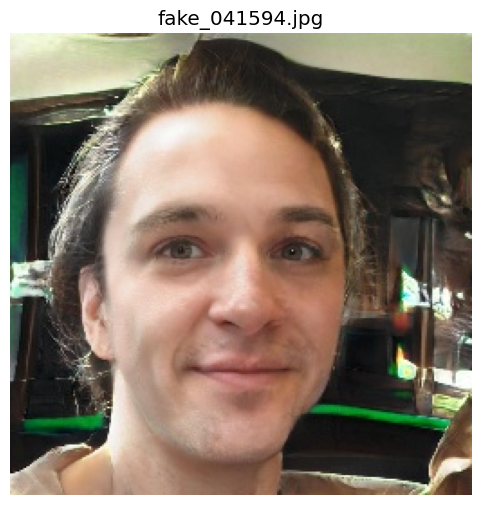

In [ ]:
def resolve_input_image(local_image: str | Path | None = None, image_url: str | None = None) -> Path:
    if image_url:
        parsed = urlparse(image_url)
        filename = Path(parsed.path).name or 'downloaded_image.jpg'
        target = DOWNLOAD_DIR / filename
        response = requests.get(image_url, timeout=60)
        response.raise_for_status()
        target.write_bytes(response.content)
        return target

    if local_image:
        local_path = Path(local_image).expanduser().resolve()
        if local_path.exists():
            return local_path

    raise FileNotFoundError('Define una ruta valida en LOCAL_IMAGE o una URL valida en IMAGE_URL.')


INPUT_IMAGE = resolve_input_image(LOCAL_IMAGE, IMAGE_URL)
preview = Image.open(INPUT_IMAGE).convert('RGB')

print(f'Imagen seleccionada: {INPUT_IMAGE}')
plt.figure(figsize=(6, 6))
plt.imshow(preview)
plt.axis('off')
plt.title(INPUT_IMAGE.name)
plt.show()

## 7. Inferencia y lectura del resultado

La salida muestra:
- la etiqueta final (`real` o `fake`)
- la confianza de la mejor prediccion
- un grafico con las probabilidades por clase


image 1/1 C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata\test\fake\fake_041594.jpg: 224x224 fake 1.00, real 0.00, 5.9ms
Speed: 3.2ms preprocess, 5.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
Prediccion final: fake (100.00%)
  - fake: 100.00%
  - real: 0.00%


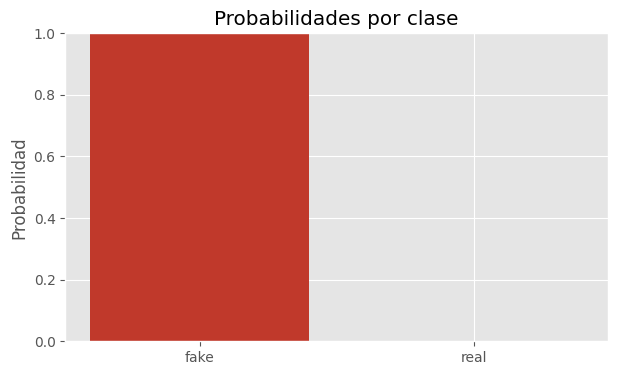

In [ ]:
prediction = classify_image(INPUT_IMAGE, model_path=selected_model)
scores = prediction['scores']
labels = [label for label, _ in scores]
values = [score for _, score in scores]

print(f"Prediccion final: {prediction['label']} ({prediction['confidence']:.2%})")
for label, score in scores:
    print(f'  - {label}: {score:.2%}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, values, color=['#c0392b', '#1f78b4'][: len(labels)])
ax.set_ylim(0, 1)
ax.set_ylabel('Probabilidad')
ax.set_title('Probabilidades por clase')
plt.show()

## 8. Recomendaciones de uso

- Para entrenar de verdad, sube `EPOCHS` y deja `FRACTION = 1.0`.
- Para pruebas rapidas del pipeline, usa una fraccion pequeña del dataset.
- Si quieres comparar modelos, cambia `MODEL_PATH` y vuelve a ejecutar las celdas de seleccion de modelo e inferencia.
- Si este notebook te funciona como version canonica, los cuadernos antiguos pueden pasar a archivo historico o borrarse mas adelante.